# Notebook 11 — Coverage Analysis

Using the tagged works corpus from Notebooks 09–10, answer:
1. **Quadrant plot** — work importance vs. concept yield
2. **Concept coverage** — which composite concepts does the corpus cover?
3. **Hirsch coverage** — which of the 6,900 Hirsch terms appear in at least one work?
4. **Gap identification** — high-salience concepts with no work coverage
5. **Age-tier breakdown** — coverage per curriculum tier
6. **Medium balance** — films vs. novels

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

DATA_DIR = Path('../data')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 11


def normalize(text):
    if not isinstance(text, str):
        return ''
    s = unicodedata.normalize('NFKD', text)
    s = ''.join(c for c in s if not unicodedata.combining(c))
    s = s.lower().strip()
    s = re.sub(r'^(the|a|an)\s+', '', s)
    s = re.sub(r"[,;:!?'\"()\[\]]", '', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s


print('Ready.')

Ready.


## 1. Load Data

In [2]:
works   = pd.read_csv(DATA_DIR / 'works_corpus.csv')
tags    = pd.read_csv(DATA_DIR / 'work_concept_tags.csv')
yield_df = pd.read_csv(DATA_DIR / 'work_concept_yield.csv')
hirsch  = pd.read_csv(DATA_DIR / 'hirsch_cultural_literacy_terms.csv')
composite = pd.read_csv(
    DATA_DIR / 'cultural_salience_composite_v2.csv',
    dtype={'wiki_title': str, 'qid': str},
    low_memory=False,
)

# Merge yield into works
works_full = works.merge(
    yield_df[['work_id', 'n_matched', 'concept_yield', 'avg_score']],
    on='work_id', how='left'
)
works_full['concept_yield']  = works_full['concept_yield'].fillna(0)
works_full['n_matched']      = works_full['n_matched'].fillna(0).astype(int)
works_full['importance_score'] = works_full['importance_score'].fillna(works_full['importance_score'].median())

# Normalize concept names for Hirsch matching
hirsch['norm'] = hirsch['term'].apply(normalize)

def flip_name(term):
    if ', ' in str(term):
        parts = term.split(', ', 1)
        if len(parts) == 2 and parts[1][:1].isupper():
            return normalize(f'{parts[1]} {parts[0]}')
    return None

hirsch['norm_flip'] = hirsch['term'].apply(flip_name)

print(f'Works       : {len(works_full):,}')
print(f'Tag rows    : {len(tags):,}  (matched: {tags["matched_concept"].notna().sum():,})')
print(f'Hirsch terms: {len(hirsch):,}')
print(f'\nworks_full importance_score range: {works_full["importance_score"].min():.1f} – {works_full["importance_score"].max():.1f}')
print(f'works_full concept_yield   range: {works_full["concept_yield"].min():.0f} – {works_full["concept_yield"].max():.0f}')

Works       : 883
Tag rows    : 20,903  (matched: 9,263)
Hirsch terms: 6,953

works_full importance_score range: 0.8 – 100.0
works_full concept_yield   range: 0 – 5398


## 2. Quadrant Plot — Importance vs. Concept Yield

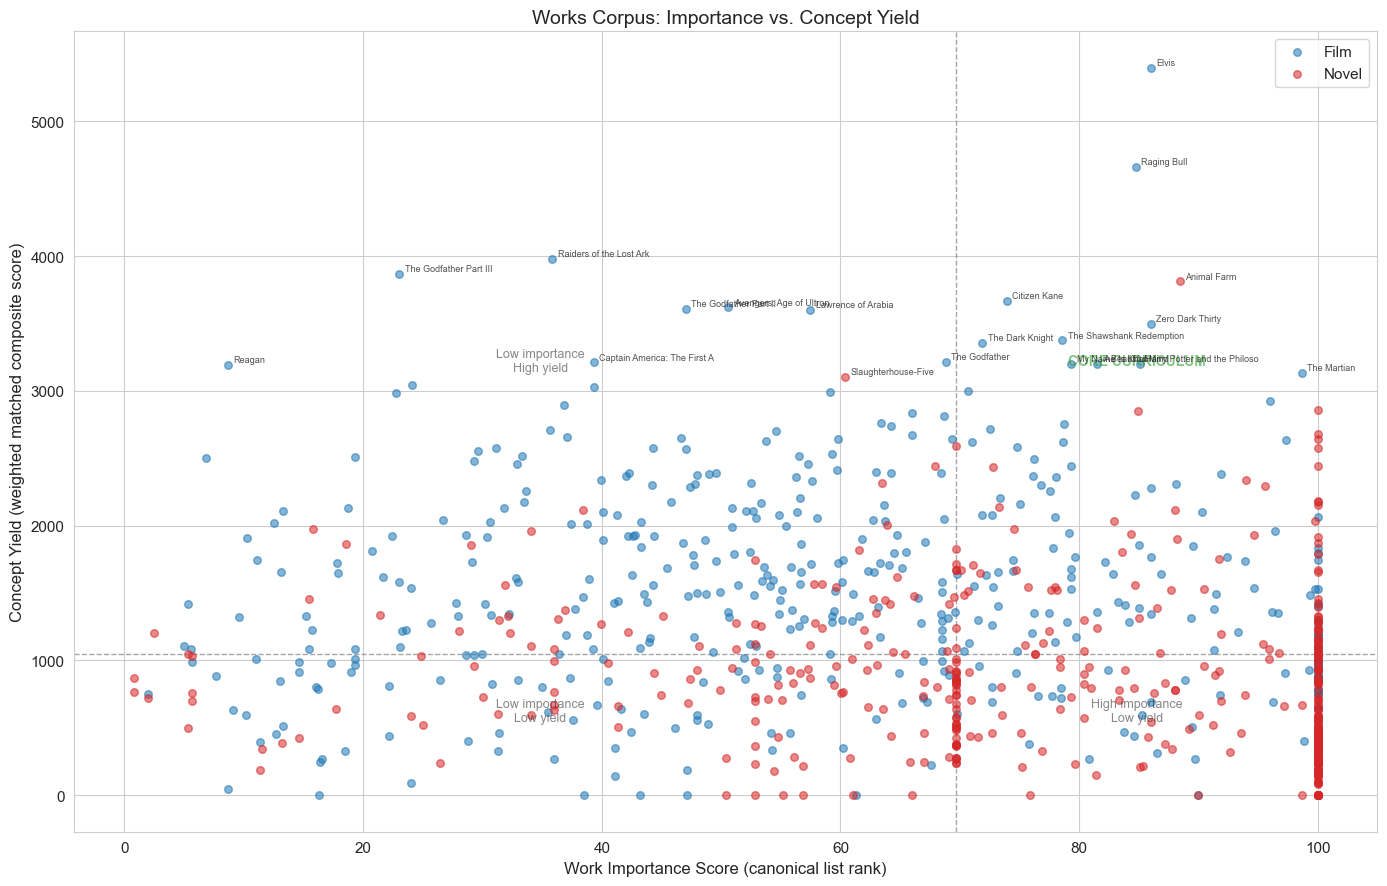

High imp / High yield (Core)       : 183
High imp / Low  yield (Narrow)     : 280
Low  imp / High yield (Encyclopedic): 259
Low  imp / Low  yield (Consider)   : 161


In [3]:
imp_med   = works_full['importance_score'].median()
yield_med = works_full['concept_yield'].median()

COLORS = {'film': '#1f77b4', 'novel': '#d62728'}

fig, ax = plt.subplots(figsize=(14, 9))

for med, grp in works_full.groupby('medium'):
    ax.scatter(
        grp['importance_score'], grp['concept_yield'],
        c=COLORS[med], alpha=0.55, s=30, label=med.capitalize(), zorder=3,
    )

# Quadrant lines
ax.axvline(imp_med,   color='grey', lw=1, ls='--', alpha=0.7)
ax.axhline(yield_med, color='grey', lw=1, ls='--', alpha=0.7)

# Quadrant labels
xmax = works_full['importance_score'].max()
ymax = works_full['concept_yield'].max()
kw   = dict(fontsize=9, alpha=0.55, ha='center', va='center')
ax.text((imp_med + xmax) / 2, yield_med * 0.6, 'High importance\nLow yield', **kw)
ax.text((imp_med + xmax) / 2, (yield_med + ymax) / 2, 'CORE CURRICULUM', fontsize=10,
        alpha=0.6, ha='center', va='center', fontweight='bold', color='#2ca02c')
ax.text(imp_med * 0.5, (yield_med + ymax) / 2, 'Low importance\nHigh yield', **kw)
ax.text(imp_med * 0.5, yield_med * 0.6, 'Low importance\nLow yield', **kw)

# Label top works
top = works_full.nlargest(20, 'concept_yield')
for _, r in top.iterrows():
    ax.annotate(
        r['title'][:28], (r['importance_score'], r['concept_yield']),
        fontsize=6.5, alpha=0.8,
        xytext=(4, 2), textcoords='offset points',
    )

ax.set_xlabel('Work Importance Score (canonical list rank)', fontsize=12)
ax.set_ylabel('Concept Yield (weighted matched composite score)', fontsize=12)
ax.set_title('Works Corpus: Importance vs. Concept Yield', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(DATA_DIR / 'quadrant_importance_yield.png', dpi=150)
plt.show()

# Quadrant counts
q_HH = ((works_full['importance_score'] >= imp_med) & (works_full['concept_yield'] >= yield_med)).sum()
q_HL = ((works_full['importance_score'] >= imp_med) & (works_full['concept_yield'] <  yield_med)).sum()
q_LH = ((works_full['importance_score'] <  imp_med) & (works_full['concept_yield'] >= yield_med)).sum()
q_LL = ((works_full['importance_score'] <  imp_med) & (works_full['concept_yield'] <  yield_med)).sum()
print(f'High imp / High yield (Core)       : {q_HH}')
print(f'High imp / Low  yield (Narrow)     : {q_HL}')
print(f'Low  imp / High yield (Encyclopedic): {q_LH}')
print(f'Low  imp / Low  yield (Consider)   : {q_LL}')

## 3. Concept Coverage of the Composite Dataset

In [4]:
# Which composite concepts are covered by at least 1 work?
matched_tags = tags[tags['matched_concept'].notna()].copy()
covered_concepts = set(matched_tags['matched_concept'].str.lower().unique())

# Build coverage table by composite score bucket
composite['norm'] = composite['concept'].apply(normalize)
composite['covered'] = composite['concept'].str.lower().isin(covered_concepts)

bucket_edges = [0, 40, 55, 70, 85, 101]
bucket_labels = ['0–40', '40–55', '55–70', '70–85', '85–100']
composite['score_bucket'] = pd.cut(
    composite['composite_score'], bins=bucket_edges, labels=bucket_labels, right=False
)

cov_by_bucket = composite.groupby('score_bucket', observed=True).agg(
    total=('concept', 'count'),
    covered=('covered', 'sum'),
).assign(pct=lambda d: 100 * d['covered'] / d['total'])

print('Concept coverage by composite score bucket:')
print(cov_by_bucket.to_string(float_format='{:.1f}'.format))

top_comp = composite[composite['composite_score'] >= 70]
top_covered = top_comp['covered'].sum()
print(f'\nTop concepts (score>=70): {top_covered:,} / {len(top_comp):,} covered ({100*top_covered/len(top_comp):.1f}%)')

# Coverage by entity type (top-70 concepts)
print('\nCoverage by entity type (score>=70):')
et_cov = top_comp.groupby('entity_type').agg(
    total=('concept','count'), covered=('covered','sum')
).assign(pct=lambda d: 100*d['covered']/d['total']).sort_values('total', ascending=False).head(12)
print(et_cov.to_string(float_format='{:.1f}'.format))

Concept coverage by composite score bucket:
              total  covered  pct
score_bucket                     
0–40          67451        0  0.0
40–55         92171      550  0.6
55–70         22306      878  3.9
70–85         18339     1089  5.9
85–100         9414      943 10.0

Top concepts (score>=70): 2,032 / 27,753 covered (7.3%)

Coverage by entity type (score>=70):
             total  covered  pct
entity_type                     
CONCEPT       7424      205  2.8
PERSON        6673      699 10.5
UNKNOWN       3533      241  6.8
WORK_OF_ART   2897      277  9.6
GPE           2853      334 11.7
ORG           2179      121  5.6
LOC           1139       38  3.3
NORP           495       68 13.7
EVENT          338       36 10.7
PRODUCT        132        2  1.5
FAC             52        5  9.6
LANGUAGE        19        6 31.6


## 4. Hirsch Term Coverage

Hirsch term coverage: 717 / 6,953 (10.3%)

Coverage by section:
                                            total  covered  pct
section                                                        
American Politics                             360      141 39.2
World Politics                                168       59 35.1
American History since 1865                   327       84 25.7
World Literature, Philosophy, and Religion    589      101 17.1
Conventions of Written English                148       22 14.9
The Bible                                     157       23 14.6
Mythology and Folklore                        250       36 14.4
Fine Arts                                     279       37 13.3
World History since 1550                      261       27 10.3
Literature in English                         714       67  9.4
World History to 1550                         204       15  7.4
World Geography                               248       15  6.0
American History to 1865                

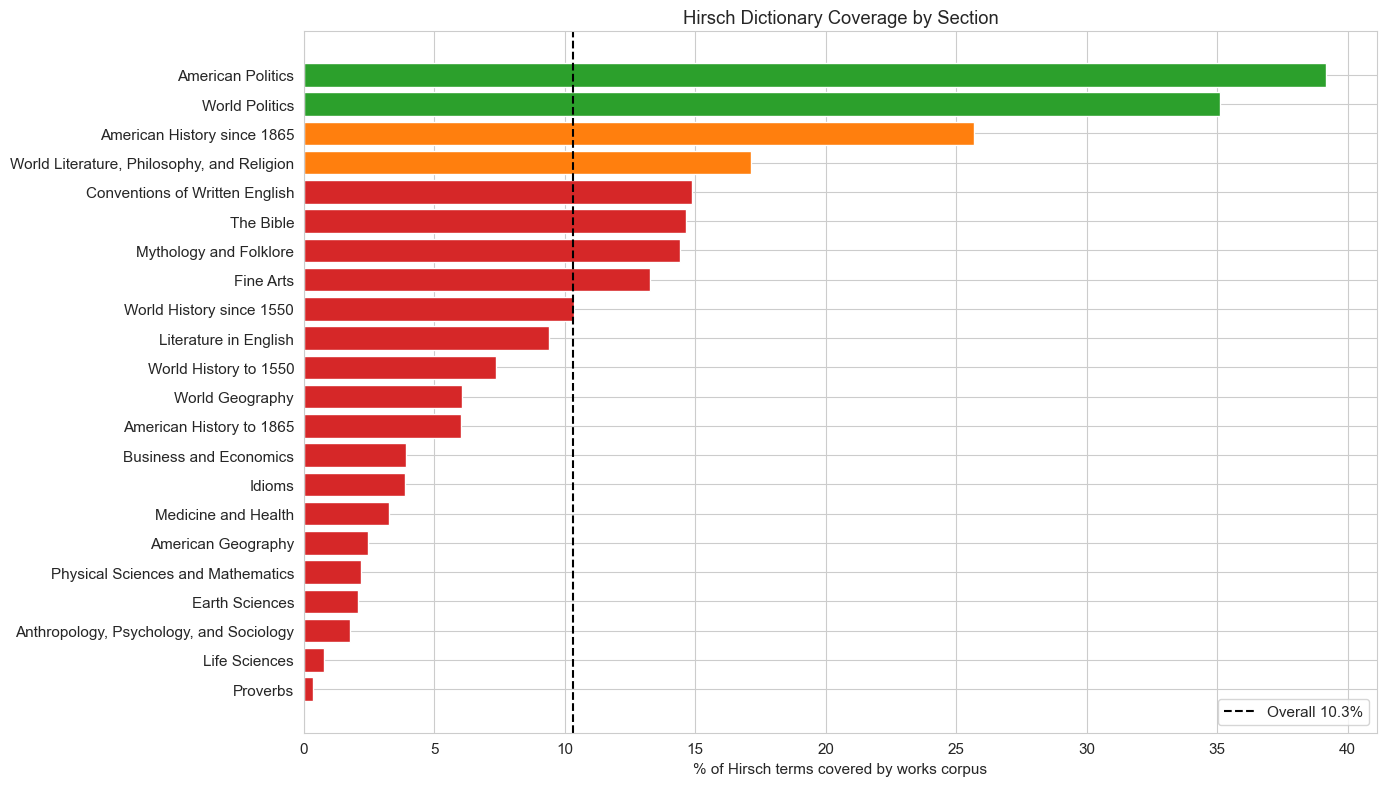

In [5]:
# Build lookup: normalized concept norms covered by the corpus
covered_norms = set(matched_tags['concept_norm'].unique()) | set(matched_tags['matched_concept'].str.lower().dropna().unique())

def hirsch_covered(row):
    n  = row['norm']
    nf = row['norm_flip']
    return bool(
        (n  and n  in covered_norms) or
        (nf and nf in covered_norms)
    )

hirsch['covered'] = hirsch.apply(hirsch_covered, axis=1)

total_covered = hirsch['covered'].sum()
print(f'Hirsch term coverage: {total_covered:,} / {len(hirsch):,} ({100*total_covered/len(hirsch):.1f}%)')

print('\nCoverage by section:')
sec_cov = hirsch.groupby('section').agg(
    total=('term','count'), covered=('covered','sum')
).assign(pct=lambda d: 100*d['covered']/d['total']).sort_values('pct', ascending=False)
print(sec_cov.to_string(float_format='{:.1f}'.format))

# Plot section coverage
fig, ax = plt.subplots(figsize=(14, 8))
sc = sec_cov.sort_values('pct')
colors = ['#2ca02c' if p >= 30 else '#ff7f0e' if p >= 15 else '#d62728' for p in sc['pct']]
ax.barh(sc.index, sc['pct'], color=colors)
ax.axvline(100*total_covered/len(hirsch), color='black', ls='--', lw=1.5, label=f'Overall {100*total_covered/len(hirsch):.1f}%')
ax.set_xlabel('% of Hirsch terms covered by works corpus')
ax.set_title('Hirsch Dictionary Coverage by Section')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'hirsch_coverage_by_section.png', dpi=150)
plt.show()

## 5. Gap Analysis — High-Salience Uncovered Concepts

In [6]:
# Top composite concepts not covered by any work
gaps = composite[
    (composite['composite_score'] >= 70) &
    (~composite['covered']) &
    (composite['entity_type'].isin(['PERSON','GPE','EVENT','NORP','LOC','WORK_OF_ART']))
].nlargest(60, 'composite_score')[[
    'concept', 'display_name', 'entity_type', 'composite_score', 'n_signals'
]]

print(f'High-salience uncovered concepts (score>=70, meaningful entity type): {len(gaps):,}')
print('\nTop 60 gaps:')
print(gaps.to_string(index=False, float_format='{:.1f}'.format))

# Gaps by entity type
gap_all = composite[
    (composite['composite_score'] >= 70) & (~composite['covered'])
]
print(f'\nAll gaps (score>=70): {len(gap_all):,}')
print('By entity type:')
print(gap_all['entity_type'].value_counts().head(12).to_string())

High-salience uncovered concepts (score>=70, meaningful entity type): 60

Top 60 gaps:
                        concept                    display_name entity_type  composite_score  n_signals
                          q2831                           Q2831      PERSON            100.0          1
                         edirne                          Edirne         GPE             99.8          1
            catherine the great             Catherine the Great      PERSON             99.8          1
            alexander the great             Alexander the Great      PERSON             99.8          2
                           star                            star         GPE             99.7          2
                          q1067                           Q1067      PERSON             99.7          1
        midsummer night's dream         Midsummer Night's Dream WORK_OF_ART             99.7          1
    declaration of independence     Declaration of Independence      PERSON      

## 6. Core Curriculum — Top Works by Combined Score

In [7]:
# Normalize both dimensions to [0,1] then combine
def minmax(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0

works_full['imp_norm']   = minmax(works_full['importance_score'])
works_full['yield_norm'] = minmax(works_full['concept_yield'])
works_full['combined']   = 0.5 * works_full['imp_norm'] + 0.5 * works_full['yield_norm']

print('Top 30 films by combined importance+yield score:')
top_films = works_full[works_full['medium']=='film'].nlargest(30, 'combined')
print(top_films[['title','year','importance_score','concept_yield','n_matched','age_tier','combined']]
      .to_string(index=False, float_format='{:.1f}'.format))

print('\nTop 30 novels by combined score:')
top_novels = works_full[works_full['medium']=='novel'].nlargest(30, 'combined')
print(top_novels[['title','year','importance_score','concept_yield','n_matched','age_tier','combined']]
      .to_string(index=False, float_format='{:.1f}'.format))

Top 30 films by combined importance+yield score:
                                   title   year  importance_score  concept_yield  n_matched age_tier  combined
                                   Elvis 2022.0              86.0         5398.5         35    adult       0.9
                             Raging Bull 1980.0              84.7         4662.1         32    adult       0.9
                             The Martian 2015.0              98.7         3131.4         29    adult       0.8
                        Zero Dark Thirty 2012.0              86.0         3499.8         29    adult       0.8
                                 Lincoln 2012.0              96.0         2928.9         24    adult       0.8
                       Kingdom of Heaven 2005.0              97.3         2635.6         23    adult       0.7
Harry Potter and the Philosopher's Stone 2001.0              85.1         3203.1         29    adult       0.7
                            Citizen Kane 1941.0              73

## 7. Age-Tier Breakdown

In [8]:
tier_order = ['child', 'middle', 'ya', 'adult']

tier_stats = works_full.groupby('age_tier').agg(
    n_works        = ('work_id', 'count'),
    avg_importance = ('importance_score', 'mean'),
    avg_yield      = ('concept_yield', 'mean'),
    total_yield    = ('concept_yield', 'sum'),
    avg_matched    = ('n_matched', 'mean'),
).reindex([t for t in tier_order if t in works_full['age_tier'].unique()])

print('Coverage by age tier:')
print(tier_stats.to_string(float_format='{:.1f}'.format))

# Unique concepts covered per tier (via tag table)
tags_with_tier = matched_tags.merge(
    works_full[['work_id','age_tier']], on='work_id', how='left'
)
print('\nUnique matched concepts covered per tier:')
for tier in tier_order:
    subset = tags_with_tier[tags_with_tier['age_tier'] == tier]
    n_unique = subset['matched_concept'].nunique()
    n_works  = subset['work_id'].nunique()
    print(f'  {tier:8s}: {n_works:4d} works  →  {n_unique:,} unique concepts')

Coverage by age tier:
          n_works  avg_importance  avg_yield  total_yield  avg_matched
age_tier                                                              
child          13            68.6     1688.5      21950.3         14.4
middle         26            64.5     1957.2      50887.5         18.1
ya             15            50.9     2299.6      34493.5         19.9
adult         829            68.4     1135.9     941647.1         10.0

Unique matched concepts covered per tier:
  child   :   13 works  →  153 unique concepts
  middle  :   26 works  →  330 unique concepts
  ya      :   15 works  →  251 unique concepts
  adult   :  799 works  →  3,240 unique concepts


## 8. Medium Balance

Coverage by medium:
  film  : 444 works  avg_importance=58.9  avg_yield=1520  unique_concepts=2,548
  novel : 439 works  avg_importance=77.3  avg_yield=852  unique_concepts=1,430

Shared concepts   : 518
Film-only concepts: 2,030
Novel-only concepts: 912


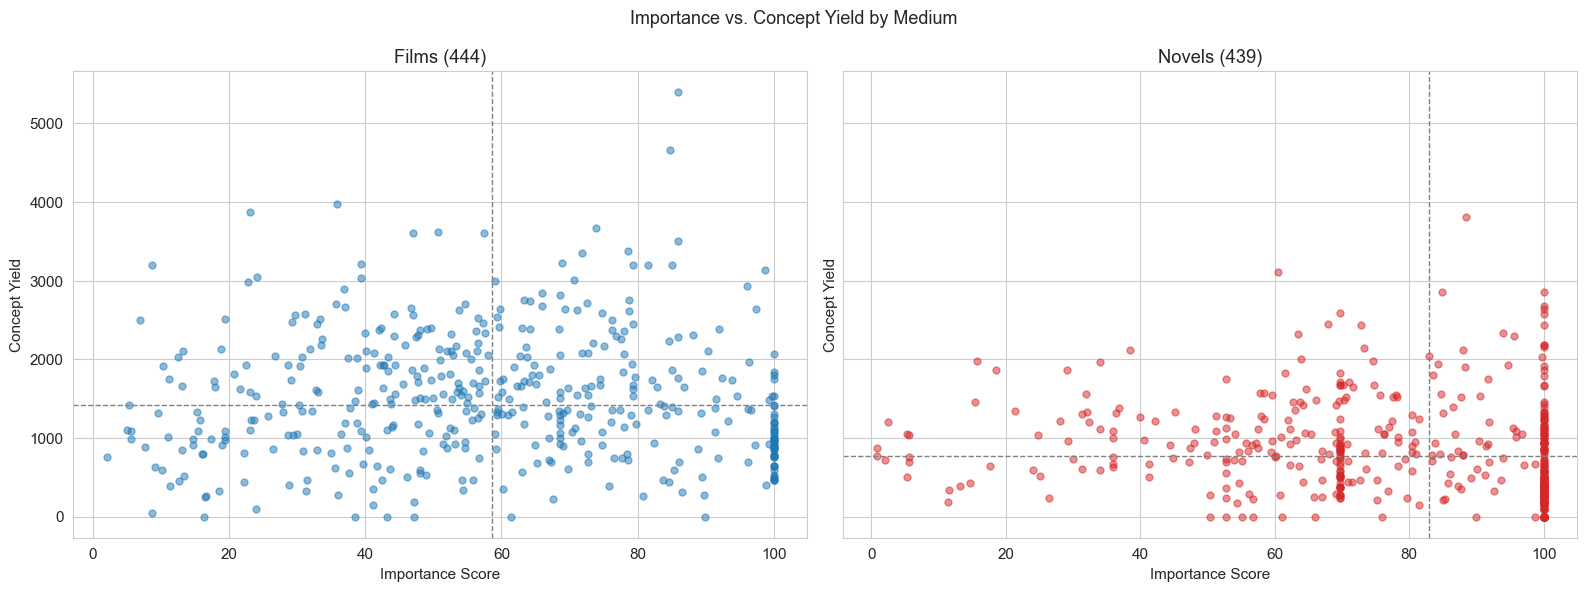

In [9]:
print('Coverage by medium:')
for med in ['film', 'novel']:
    sub = works_full[works_full['medium'] == med]
    n_works = len(sub)
    avg_imp = sub['importance_score'].mean()
    avg_yld = sub['concept_yield'].mean()
    n_concepts = matched_tags[matched_tags['work_id'].isin(sub['work_id'])]['matched_concept'].nunique()
    print(f'  {med:6s}: {n_works} works  avg_importance={avg_imp:.1f}  avg_yield={avg_yld:.0f}  unique_concepts={n_concepts:,}')

# Concepts exclusive to one medium
film_concepts  = set(matched_tags[matched_tags['work_id'].isin(works_full[works_full['medium']=='film']['work_id'])]['matched_concept'].dropna())
novel_concepts = set(matched_tags[matched_tags['work_id'].isin(works_full[works_full['medium']=='novel']['work_id'])]['matched_concept'].dropna())
shared = film_concepts & novel_concepts
film_only  = film_concepts  - novel_concepts
novel_only = novel_concepts - film_concepts
print(f'\nShared concepts   : {len(shared):,}')
print(f'Film-only concepts: {len(film_only):,}')
print(f'Novel-only concepts: {len(novel_only):,}')

# Importance vs yield scatter by medium
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, med, color in zip(axes, ['film','novel'], ['#1f77b4','#d62728']):
    sub = works_full[works_full['medium']==med]
    ax.scatter(sub['importance_score'], sub['concept_yield'], c=color, alpha=0.5, s=25)
    ax.axvline(sub['importance_score'].median(), color='grey', ls='--', lw=1)
    ax.axhline(sub['concept_yield'].median(),    color='grey', ls='--', lw=1)
    ax.set_xlabel('Importance Score')
    ax.set_ylabel('Concept Yield')
    ax.set_title(f'{med.capitalize()}s ({len(sub)})')
plt.suptitle('Importance vs. Concept Yield by Medium', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'quadrant_by_medium.png', dpi=150)
plt.show()

## 9. Export Coverage Summary

In [10]:
# Works with combined score — to be used as input to Notebook 12
works_scored = works_full[[
    'work_id','title','medium','year','age_tier',
    'importance_score','concept_yield','n_matched','combined',
    'imp_norm','yield_norm','cluster_id',
]].sort_values('combined', ascending=False)

works_scored.to_csv(DATA_DIR / 'works_scored.csv', index=False)
print(f'Saved works_scored.csv: {len(works_scored):,} works')

# Uncovered Hirsch terms
hirsch_gaps = hirsch[~hirsch['covered']]
hirsch_gaps.to_csv(DATA_DIR / 'hirsch_gaps.csv', index=False)
print(f'Saved hirsch_gaps.csv : {len(hirsch_gaps):,} uncovered Hirsch terms')

# High-salience uncovered composite concepts
concept_gaps = composite[
    (composite['composite_score'] >= 60) & (~composite['covered'])
][['concept','display_name','entity_type','composite_score','n_signals']]\
    .sort_values('composite_score', ascending=False)
concept_gaps.to_csv(DATA_DIR / 'concept_gaps.csv', index=False)
print(f'Saved concept_gaps.csv: {len(concept_gaps):,} uncovered concepts with score>=60')

print('\n=== FINAL SUMMARY ===')
print(f'Works corpus         : {len(works):,} works ({(works["medium"]=="film").sum()} films, {(works["medium"]=="novel").sum()} novels)')
print(f'Tagged works         : {tags["work_id"].nunique():,}')
print(f'Total concept tags   : {len(tags):,}')
print(f'Matched to composite : {tags["matched_concept"].notna().sum():,} ({100*tags["matched_concept"].notna().mean():.1f}%)')
print(f'Unique concepts hit  : {matched_tags["matched_concept"].nunique():,}')
print(f'Hirsch coverage      : {hirsch["covered"].sum():,} / {len(hirsch):,} ({100*hirsch["covered"].mean():.1f}%)')
print(f'\nOutputs written:')
for f in ['works_scored.csv','hirsch_gaps.csv','concept_gaps.csv',
          'quadrant_importance_yield.png','hirsch_coverage_by_section.png','quadrant_by_medium.png']:
    p = DATA_DIR / f
    size = p.stat().st_size if p.exists() else 0
    print(f'  {f:45s} {size:>8,} bytes')

Saved works_scored.csv: 883 works
Saved hirsch_gaps.csv : 6,236 uncovered Hirsch terms
Saved concept_gaps.csv: 41,667 uncovered concepts with score>=60

=== FINAL SUMMARY ===
Works corpus         : 883 works (444 films, 439 novels)
Tagged works         : 881
Total concept tags   : 20,903
Matched to composite : 9,263 (44.3%)
Unique concepts hit  : 3,460
Hirsch coverage      : 717 / 6,953 (10.3%)

Outputs written:
  works_scored.csv                               121,361 bytes
  hirsch_gaps.csv                                414,174 bytes
  concept_gaps.csv                              2,187,111 bytes
  quadrant_importance_yield.png                  230,370 bytes
  hirsch_coverage_by_section.png                 127,159 bytes
  quadrant_by_medium.png                         144,353 bytes
